#AI-Powered Lead Scoring & Sales Automation System

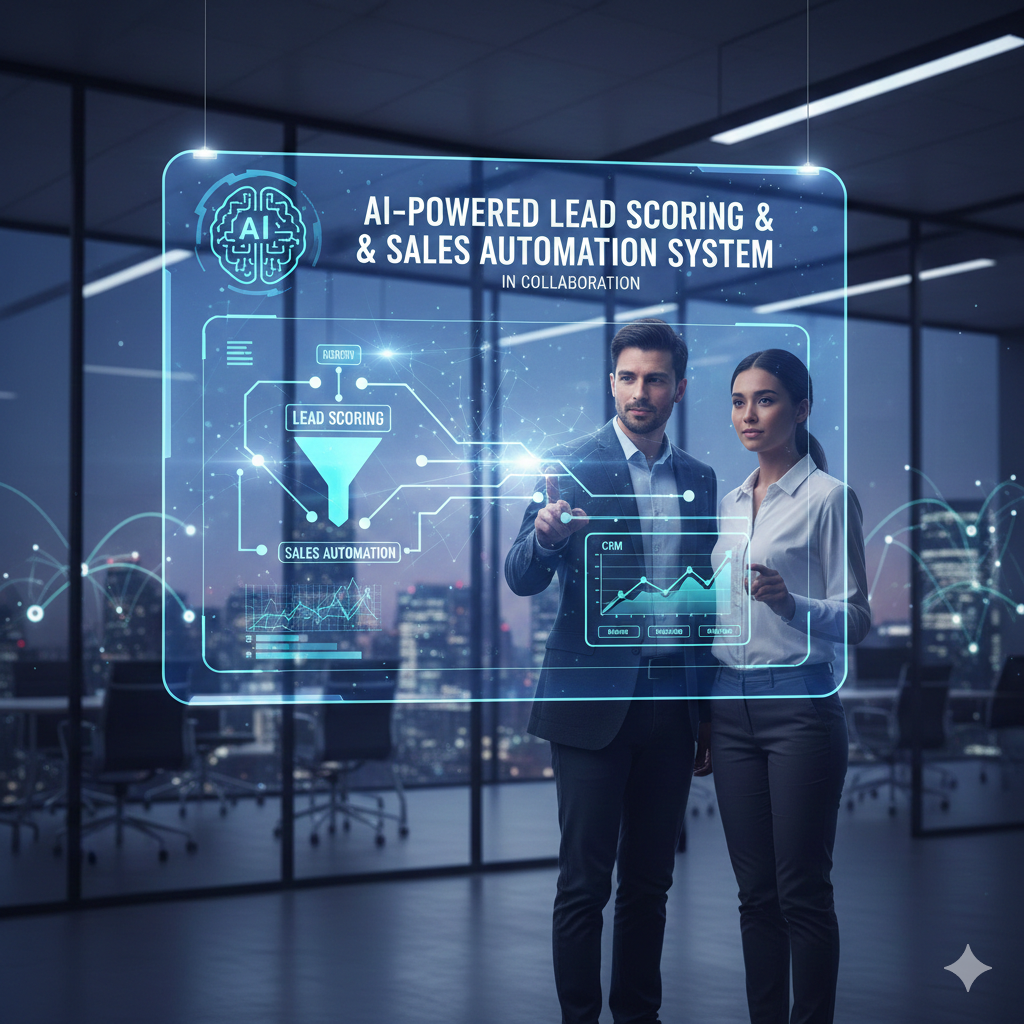

1. Executive Summary: A X-Education company generates a large number of leads through several websites on Google, when people fill up the form or watch videos by providing their Email address or phone number. out of these leads generated ~30% gets converted. The sales team spends time calling every lead, reducing efficiency.

   The project an AI-driven system that:
   
   - Predicts lead conversion probability
   - Assigns a lead score (0-100)
   - Categorizes leads (Hot/Warm/Cold)
   - Recommends next best sales action
   - Stimulates revenue impact
   - Deploys an interactive scoring application


2. Business Problem:

    Current situation:

    - 100 leads per day only 30 converts
    - sales team calls every one, wasted efort on low intent leads, low productivity

     Core problem:

     - Sales team lacks a priortization mechanism

     Business Need:

     A system to:

     - Identify high-conversion probability leads
     - Focus sales effort on high value-prospects
     - Increase conversion efficiency
     - Increase ROI

3. Business Objective:

   Primary: Build a predictive model to assign a score to each lead such that, leads with higher score have significantly higher probability of conversion.

   Strategic goal:

   if sales focuses on top 30- 40% of leads:
   
   - Achieve ~70-80% precision
   - improve conversion efficiency
   - Increase revenue per sales agent





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Lead Scoring.csv")

In [3]:
Lead = df.copy()

In [4]:
df.shape

(9240, 37)

In [5]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [6]:
df.tail()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
9235,19d6451e-fcd6-407c-b83b-48e1af805ea9,579564,Landing Page Submission,Direct Traffic,Yes,No,1,8.0,1845,2.67,...,No,Potential Lead,Mumbai,02.Medium,01.High,15.0,17.0,No,No,Email Marked Spam
9236,82a7005b-7196-4d56-95ce-a79f937a158d,579546,Landing Page Submission,Direct Traffic,No,No,0,2.0,238,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,19.0,No,Yes,SMS Sent
9237,aac550fe-a586-452d-8d3c-f1b62c94e02c,579545,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,199,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,13.0,20.0,No,Yes,SMS Sent
9238,5330a7d1-2f2b-4df4-85d6-64ca2f6b95b9,579538,Landing Page Submission,Google,No,No,1,3.0,499,3.00,...,No,NaN,Other Metro Cities,02.Medium,02.Medium,15.0,16.0,No,No,SMS Sent
9239,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,579533,Landing Page Submission,Direct Traffic,No,No,1,6.0,1279,3.00,...,No,Potential Lead,Other Cities,02.Medium,01.High,15.0,18.0,No,Yes,Modified


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Lead Number,9240.0,617188.435606,23405.995698,579533.0,596484.5,615479.0,637387.25,660737.0
Converted,9240.0,0.385390,0.486714,0.0,0.0,0.0,1.00,1.0
TotalVisits,9103.0,3.445238,4.854853,0.0,1.0,3.0,5.00,251.0
Total Time Spent on Website,9240.0,487.698268,548.021466,0.0,12.0,248.0,936.00,2272.0
Page Views Per Visit,9103.0,2.362820,2.161418,0.0,1.0,2.0,3.00,55.0
Asymmetrique Activity Score,5022.0,14.306252,1.386694,7.0,14.0,14.0,15.00,18.0
Asymmetrique Profile Score,5022.0,16.344883,1.811395,11.0,15.0,16.0,18.00,20.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop(['Prospect ID', 'Lead Number'], axis =1, inplace = True)

In [11]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [12]:
df.isnull().sum()/df.shape[0]*100

,0
Lead_Origin,0.000000
Lead_Source,0.389610
Do_Not_Email,0.000000
Do_Not_Call,0.000000
Converted,0.000000
TotalVisits,1.482684
Total_Time_Spent_on_Website,0.000000
Page_Views_Per_Visit,1.482684
Last_Activity,1.114719
Country,26.634199


In [13]:
df['Lead_Source'].unique()

array(['Olark Chat', 'Organic Search', 'Direct Traffic', 'Google',
       'Referral Sites', 'Welingak Website', 'Reference', 'google',
       'Facebook', nan, 'blog', 'Pay per Click Ads', 'bing',
       'Social Media', 'WeLearn', 'Click2call', 'Live Chat',
       'welearnblog_Home', 'youtubechannel', 'testone', 'Press_Release',
       'NC_EDM'], dtype=object)

In [14]:
df['Lead_Source']= df['Lead_Source'].str.lower()

In [15]:
df['Lead_Source'].unique()

array(['olark chat', 'organic search', 'direct traffic', 'google',
       'referral sites', 'welingak website', 'reference', 'facebook', nan,
       'blog', 'pay per click ads', 'bing', 'social media', 'welearn',
       'click2call', 'live chat', 'welearnblog_home', 'youtubechannel',
       'testone', 'press_release', 'nc_edm'], dtype=object)

In [16]:
df['TotalVisits'].unique()

array([  0.,   5.,   2.,   1.,   4.,   8.,  11.,   6.,   3.,   7.,  13.,
        17.,  nan,   9.,  12.,  10.,  16.,  14.,  21.,  15.,  22.,  19.,
        18.,  20.,  43.,  30.,  23.,  55., 141.,  25.,  27.,  29.,  24.,
        28.,  26.,  74.,  41.,  54., 115., 251.,  32.,  42.])

In [17]:
df['Page_Views_Per_Visit'].unique()

array([ 0.  ,  2.5 ,  2.  ,  1.  ,  4.  ,  8.  ,  2.67, 11.  ,  5.  ,
        6.  ,  3.  ,  1.33,  1.5 ,  3.5 ,  7.  ,  2.33, 13.  ,  8.5 ,
        5.5 ,  1.67,   nan,  4.5 ,  3.33, 16.  , 12.  ,  1.71,  1.8 ,
        6.5 ,  4.33, 14.  ,  3.4 , 10.  ,  1.25,  1.75,  2.63, 15.  ,
        2.25,  3.67,  1.43,  9.  ,  2.6 ,  4.75,  1.27,  3.25,  5.33,
        2.57,  2.17,  2.75,  2.8 ,  2.2 ,  2.86,  3.91,  1.4 ,  5.67,
        3.2 ,  1.38,  2.09,  2.4 , 55.  ,  5.25,  6.71,  3.57,  2.22,
        1.83,  3.6 ,  1.2 ,  1.57,  1.56,  5.4 ,  4.25,  1.31,  1.6 ,
        2.9 ,  1.23,  1.78,  3.83,  7.5 ,  1.14,  2.71,  1.45,  2.38,
        1.86,  2.29,  1.21, 12.33,  3.43,  2.56,  6.33,  1.64,  8.21,
        4.4 ,  3.17,  8.33,  1.48,  1.22, 24.  ,  3.75,  6.67,  1.54,
        2.13,  2.14,  2.45,  3.29,  4.17,  1.63,  3.38,  1.17, 14.5 ,
        3.8 ,  1.19,  3.82,  2.83,  1.93, 11.5 ,  2.08])

In [18]:
df['Last_Activity'].unique()

array(['Page Visited on Website', 'Email Opened', 'Unreachable',
       'Converted to Lead', 'Olark Chat Conversation', 'Email Bounced',
       'Email Link Clicked', 'Form Submitted on Website', 'Unsubscribed',
       'Had a Phone Conversation', 'View in browser link Clicked', nan,
       'Approached upfront', 'SMS Sent', 'Visited Booth in Tradeshow',
       'Resubscribed to emails', 'Email Received', 'Email Marked Spam'],
      dtype=object)

In [19]:
df['Country'].unique()

array([nan, 'India', 'Russia', 'Kuwait', 'Oman', 'United Arab Emirates',
       'United States', 'Australia', 'United Kingdom', 'Bahrain', 'Ghana',
       'Singapore', 'Qatar', 'Saudi Arabia', 'Belgium', 'France',
       'Sri Lanka', 'China', 'Canada', 'Netherlands', 'Sweden', 'Nigeria',
       'Hong Kong', 'Germany', 'Asia/Pacific Region', 'Uganda', 'Kenya',
       'Italy', 'South Africa', 'Tanzania', 'unknown', 'Malaysia',
       'Liberia', 'Switzerland', 'Denmark', 'Philippines', 'Bangladesh',
       'Vietnam', 'Indonesia'], dtype=object)

In [20]:
df['Country'] = df['Country'].replace('unknown', np.nan)

In [21]:
df['Specialization'].unique()

array(['Select', 'Business Administration', 'Media and Advertising', nan,
       'Supply Chain Management', 'IT Projects Management',
       'Finance Management', 'Travel and Tourism',
       'Human Resource Management', 'Marketing Management',
       'Banking, Investment And Insurance', 'International Business',
       'E-COMMERCE', 'Operations Management', 'Retail Management',
       'Services Excellence', 'Hospitality Management',
       'Rural and Agribusiness', 'Healthcare Management', 'E-Business'],
      dtype=object)

In [22]:
df['Specialization'] = df['Specialization'].replace('Select', np.nan)

In [23]:
df['How_did_you_hear_about_X_Education'].unique()

array(['Select', 'Word Of Mouth', 'Other', nan, 'Online Search',
       'Multiple Sources', 'Advertisements', 'Student of SomeSchool',
       'Email', 'Social Media', 'SMS'], dtype=object)

In [24]:
df['How_did_you_hear_about_X_Education'] = df['How_did_you_hear_about_X_Education'].replace('Select', np.nan)

In [25]:
df['What_is_your_current_occupation'].unique()

array(['Unemployed', 'Student', nan, 'Working Professional',
       'Businessman', 'Other', 'Housewife'], dtype=object)

In [26]:
df['What_matters_most_to_you_in_choosing_a_course'].unique()

array(['Better Career Prospects', nan, 'Flexibility & Convenience',
       'Other'], dtype=object)

In [27]:
df['Tags'].unique()

array(['Interested in other courses', 'Ringing',
       'Will revert after reading the email', nan, 'Lost to EINS',
       'In confusion whether part time or DLP', 'Busy', 'switched off',
       'in touch with EINS', 'Already a student',
       'Diploma holder (Not Eligible)', 'Graduation in progress',
       'Closed by Horizzon', 'number not provided', 'opp hangup',
       'Not doing further education', 'invalid number',
       'wrong number given', 'Interested  in full time MBA',
       'Still Thinking', 'Lost to Others',
       'Shall take in the next coming month', 'Lateral student',
       'Interested in Next batch', 'Recognition issue (DEC approval)',
       'Want to take admission but has financial problems',
       'University not recognized'], dtype=object)

In [28]:
df['Lead_Quality'].unique()

array(['Low in Relevance', nan, 'Might be', 'Not Sure', 'Worst',
       'High in Relevance'], dtype=object)

In [29]:
df['Lead_Profile'].unique()

array(['Select', 'Potential Lead', nan, 'Other Leads', 'Lateral Student',
       'Dual Specialization Student', 'Student of SomeSchool'],
      dtype=object)

In [30]:
df['Lead_Profile'] = df['Lead_Profile'].replace('Select', np.nan)

In [31]:
df['City'].unique()

array(['Select', 'Mumbai', nan, 'Thane & Outskirts', 'Other Metro Cities',
       'Other Cities', 'Other Cities of Maharashtra', 'Tier II Cities'],
      dtype=object)

In [32]:
df['City'] = df['City'].replace('Select', np.nan)

In [33]:
df['Asymmetrique_Activity_Index'].unique()

array(['02.Medium', '01.High', '03.Low', nan], dtype=object)

In [34]:
df['Asymmetrique_Activity_Score'].unique()

array([15., 14., 13., 17., 16., 11., 12., 10.,  9.,  8., 18., nan,  7.])

In [35]:
df['Asymmetrique_Profile_Index'].unique()

array(['02.Medium', '01.High', '03.Low', nan], dtype=object)

In [36]:
df['Through_Recommendations'].value_counts(normalize=True)*100

,proportion
Through_Recommendations,
No,99.924242
Yes,0.075758


In [37]:
cols_to_drop = [
'Do_Not_Email','Do_Not_Call','Magazine','Newspaper_Article','X_Education_Forums',
'Newspaper','Digital_Advertisement','Through_Recommendations',
'Receive_More_Updates_About_Our_Courses','Update_me_on_Supply_Chain_Content',
'Get_updates_on_DM_Content','I_agree_to_pay_the_amount_through_cheque',
'A_free_copy_of_Mastering_The_Interview'
]

df.drop(columns=cols_to_drop, inplace=True)


In [38]:
df.isnull().sum()/df.shape[0]*100

,0
Lead_Origin,0.000000
Lead_Source,0.389610
Converted,0.000000
TotalVisits,1.482684
Total_Time_Spent_on_Website,0.000000
Page_Views_Per_Visit,1.482684
Last_Activity,1.114719
Country,26.688312
Specialization,36.580087
How_did_you_hear_about_X_Education,78.463203


Exploratory Data Analysis

1.Univariate Analysis

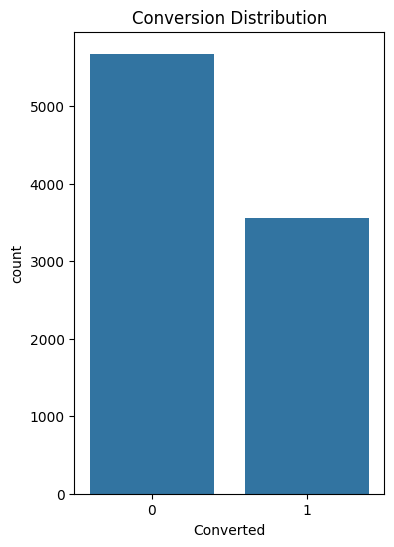

In [39]:
# Target Variable - Converted

plt.figure(figsize=(4,6))
sns.countplot(x='Converted', data=df)
plt.title('Conversion Distribution')
plt.show()

In [40]:
df['Converted'].value_counts(normalize=True)*100

,proportion
Converted,
0,61.461039
1,38.538961


- From the plot we can see that apprximately around 5600 leads are not converted that counts to around 61% and 3200 leads, around 39% converted. This implies sales team spend more time calling low probability leads, incuring more time and effort.

- The dataset show a slight imbalance, so relying solely on accuracy could be misleading, therefore considering precision, recall, AUC-ROC would be much better.

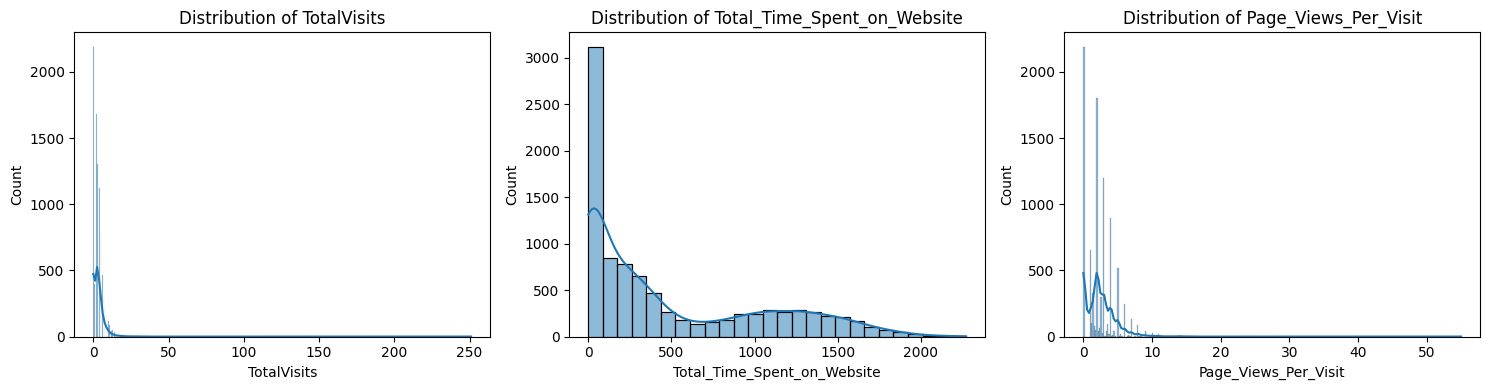

In [41]:
#Univariate Analysis- Total visits

#Histogram (Numerical columns)

num_cols = ['TotalVisits', 'Total_Time_Spent_on_Website', 'Page_Views_Per_Visit']

fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

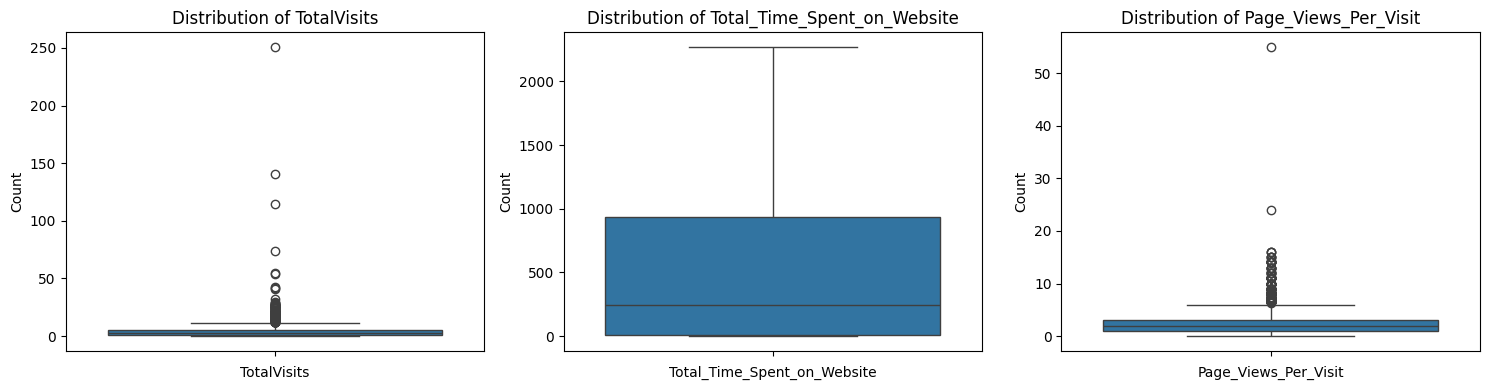

In [42]:

num_cols = ['TotalVisits', 'Total_Time_Spent_on_Website', 'Page_Views_Per_Visit']

fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))

for i, col in enumerate(num_cols):
    sns.boxplot (df[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

- Total visits: most leads visit a website very few time 0-5 in range and while some show extremely high visit frequency depicting high buyer intent

- Total time spent(in secs):many users spend a very little time less then 100 secs, while a small group spend a little time more from 1000-1500 secs suggesting deeper enegement and buying potential
- Page view per visit: Majority of thr users visit less then 5 pages only small subset of users exploring 20+ pages.


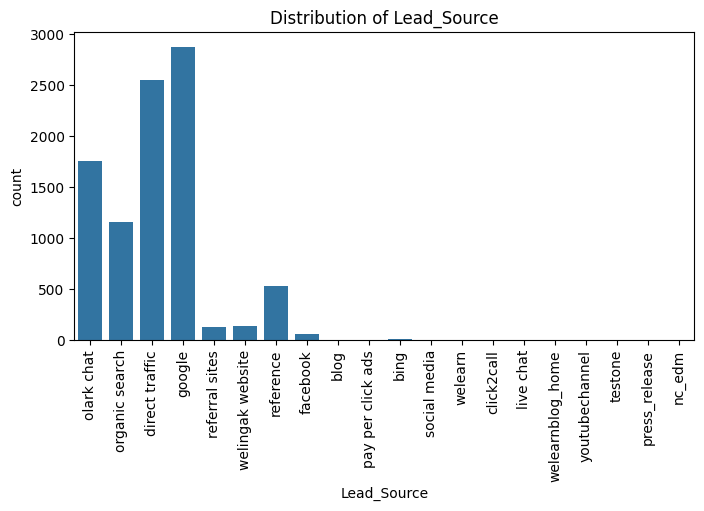

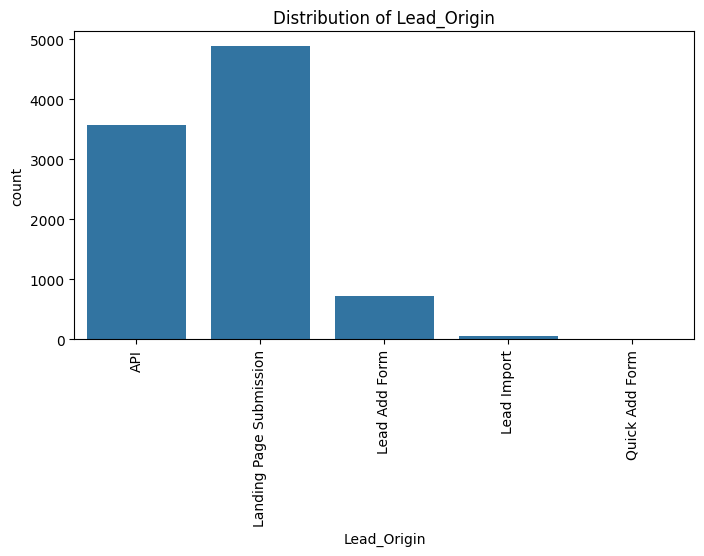

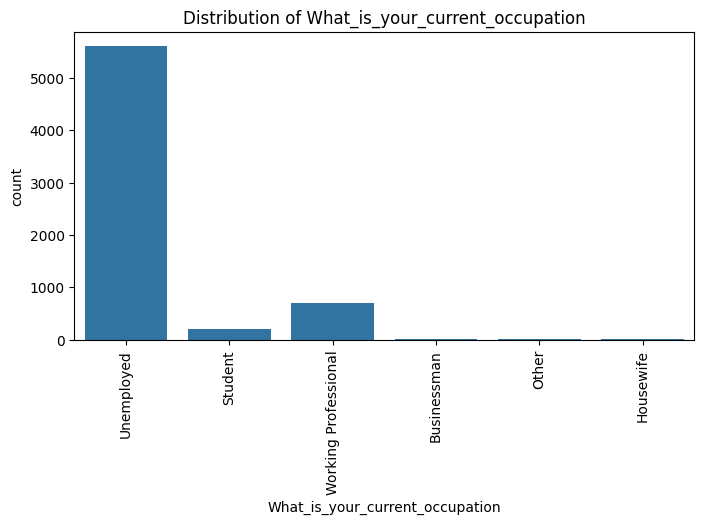

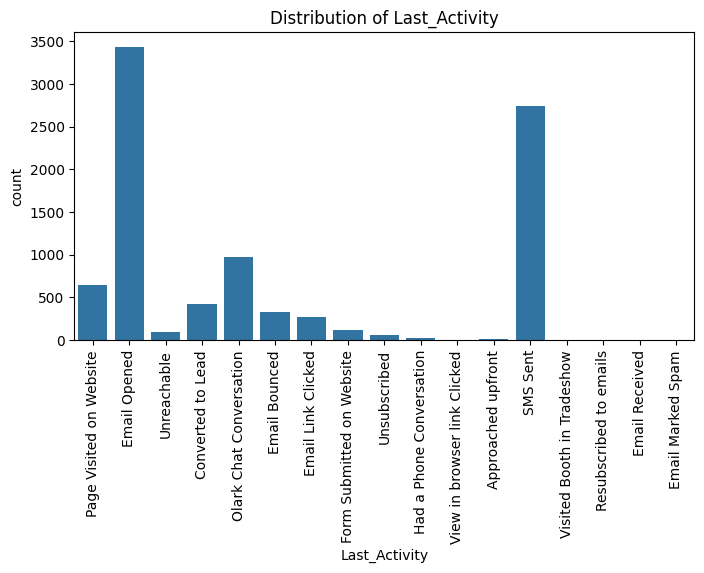

In [43]:
#Categorical variables

cat_cols = ['Lead_Source', 'Lead_Origin',
            'What_is_your_current_occupation',
            'Last_Activity']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=90)
    plt.title(f"Distribution of {col}")
    plt.show()

- Distribution of lead source: lead generation is heavily dependent on few sources like google and direct traffic actually. This indicates that marketing efforts are connetrated mainly on direct channels rather than diversified across multiple platforms

- Distribution of Lead origin: The majority of the leads come from the landing page submission and API indication website driven campaigns are primary source for for lead aquisition and should be a key focus for optimization efforts

- Distribution of current occupation: significant number of users are unemployed around 3400 this means users who visit website are mostly interested in courses which provide job opportunities, which could influence pricing strategy and conversion behaviour.

- Distribution of Last activity: The majority of the leads have email opened or sms sent as last acitivity, so nurturing startegies through these medium might influence conversion outcomes.


2.Bivariate Analysis

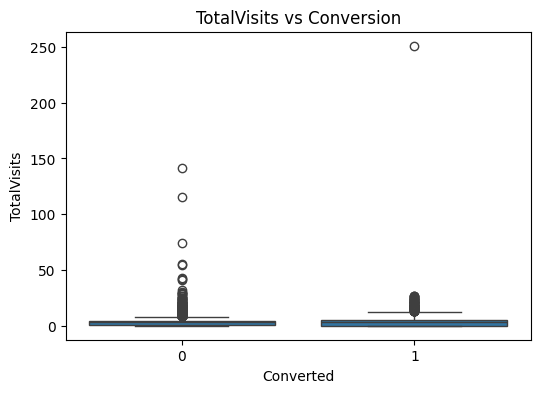

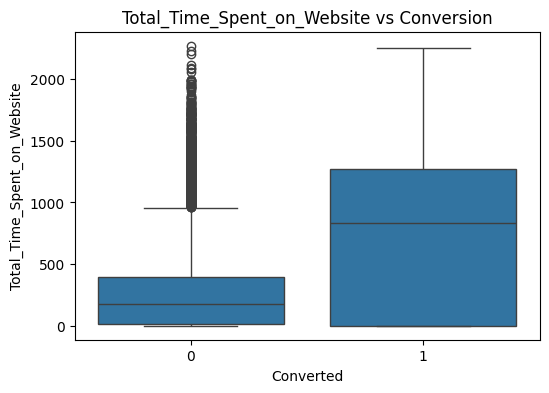

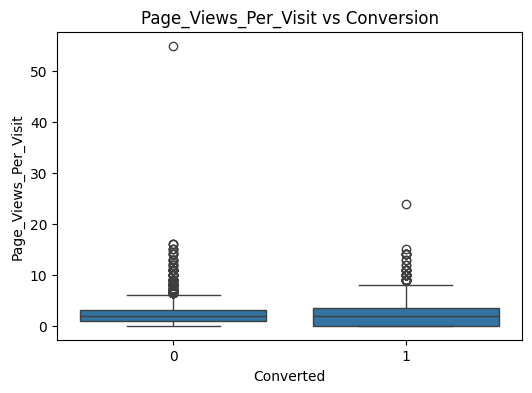

In [44]:
#EDA- Bivariate Analysis


#Numerical vs target

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Converted', y=col, data=df)
    plt.title(f"{col} vs Conversion")
    plt.show()


- Totalvisits vs conversion: Leads that tend to convert have higher visit frequency, suggests that repeated website visit indicate stronger purchase intent
- Total Time spent on website vs conversion: median time spent for converted lead significantly higher and also have much wider upper range this indicated users who spent more time on website are much more likely to convert
- Page views per visit vs conversion: higher page view is moderately associated with conversion, though the separation is less prononced compared to time spent on the website



In [45]:
#Categorical vs Target

for col in cat_cols:
    print("\n", col)
    print(pd.crosstab(df[col], df['Converted'], normalize='index') * 100)



 Lead_Source
Converted                   0           1
Lead_Source                              
bing                83.333333   16.666667
blog               100.000000    0.000000
click2call          25.000000   75.000000
direct traffic      67.833268   32.166732
facebook            76.363636   23.636364
google              60.076575   39.923425
live chat            0.000000  100.000000
nc_edm               0.000000  100.000000
olark chat          74.472934   25.527066
organic search      62.218371   37.781629
pay per click ads  100.000000    0.000000
press_release      100.000000    0.000000
reference            8.239700   91.760300
referral sites      75.200000   24.800000
social media        50.000000   50.000000
testone            100.000000    0.000000
welearn              0.000000  100.000000
welearnblog_home   100.000000    0.000000
welingak website     1.408451   98.591549
youtubechannel     100.000000    0.000000

 Lead_Origin
Converted                        0           1
L

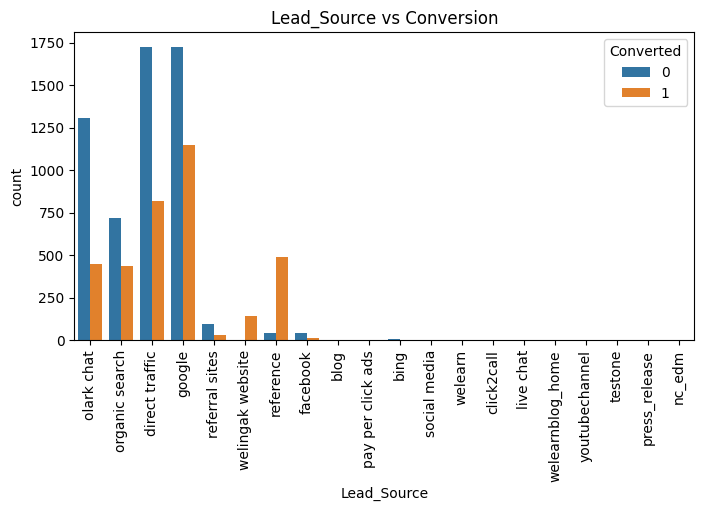

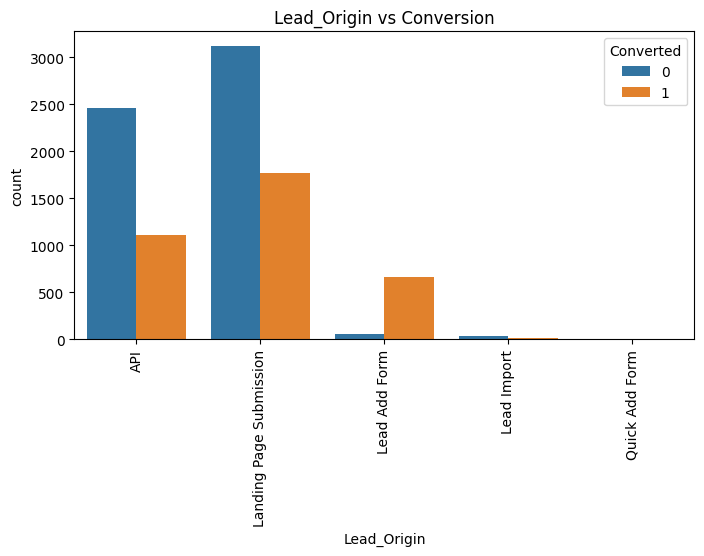

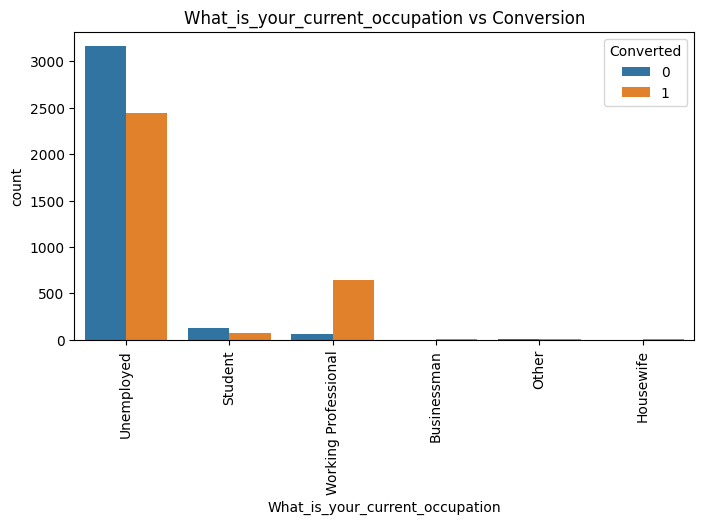

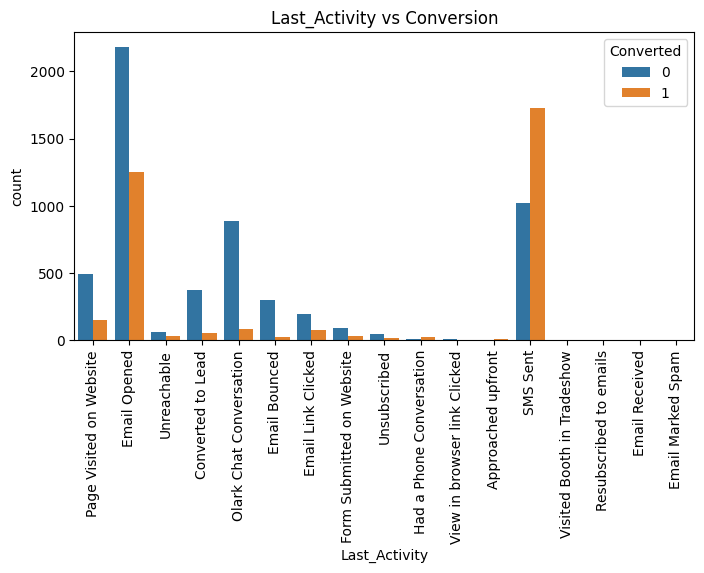

In [46]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='Converted', data=df)
    plt.xticks(rotation=90)
    plt.title(f"{col} vs Conversion")
    plt.show()


- Lead source vs conversion: Google and direct traffic are primary volume drivers but conversion efficiency is moderate, indicating opportunity for optimizing in targetting or qualification.Reference and welingak website show higher conversion efficiency suggesting stronger purchase intent.Engagement driven sources like olark chat and organic search show balanced conversion behaviour

- Lead origin vs conversion:Leads coming through the Lead Add Form show exceptionally high conversion rates, indicating they are highly qualified or high-intent prospects.Landing Page Submissions generate the highest volume of leads but convert at a moderate rate, suggesting scale-driven acquisition with mixed lead quality.API-driven leads contribute significant volume but demonstrate lower conversion efficiency compared to form-based leads.

- Current occupation vs conversion:Working professionals show a very strong tendency to convert, making them the highest-value customer segment.Although unemployed leads form the largest group, their conversion rate is moderate, indicating mixed intent or potential affordability constraints.Student leads convert at a lower rate, possibly due to financial limitations or longer decision cycles.Businessman / Other / Housewife, These segments have very low representation, making percentage-based conclusions less statistically reliable.

- Last activity vs conversion: Leads whose last activity was “SMS Sent” show significantly higher conversion counts, indicating strong follow-up engagement impact.Direct human interaction (phone conversations) strongly correlates with conversion, highlighting the importance of personalized engagement.Email engagement drives scale but not necessarily high conversion efficiency on its own.

3.Multivariate Analysis

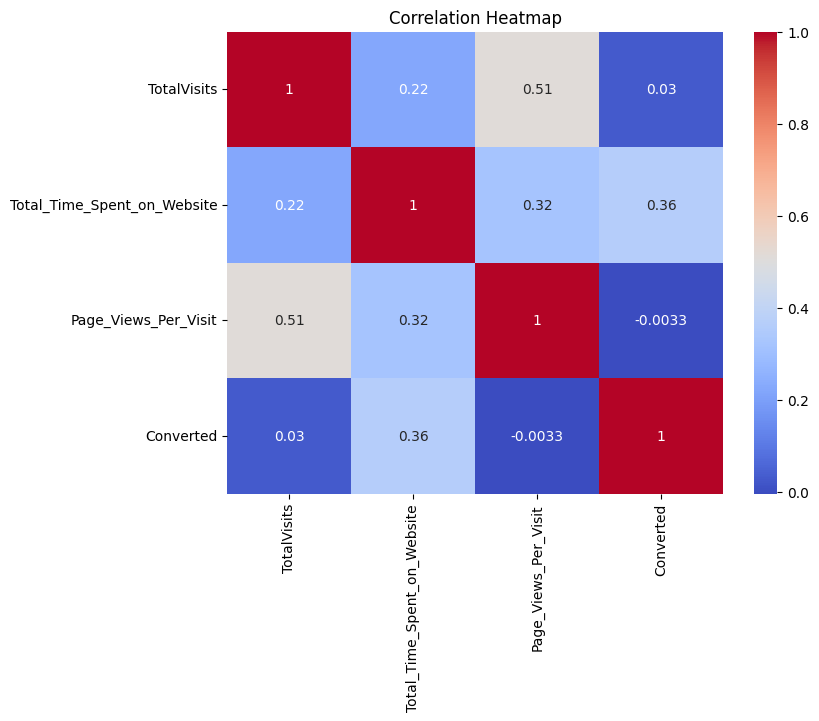

In [47]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['TotalVisits',
                'Total_Time_Spent_on_Website',
                'Page_Views_Per_Visit',
                'Converted']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


TotalVisits and Page Views Per Visit exhibit moderate inter-correlation (0.51), indicating some overlap in engagement behavior, though not severe enough to raise immediate multicollinearity concerns.

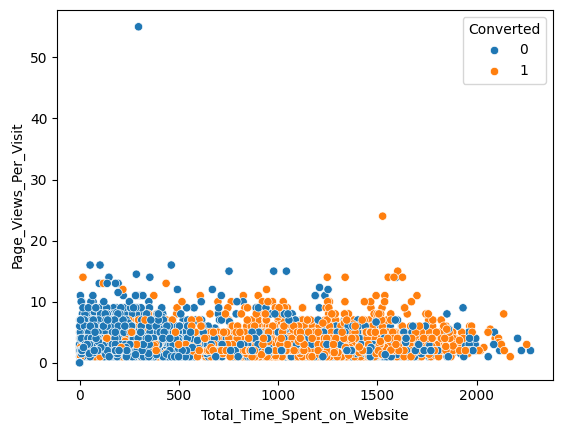

In [48]:
sns.scatterplot(x='Total_Time_Spent_on_Website',
                y='Page_Views_Per_Visit',
                hue='Converted',
                data=df)
plt.show()


- Leads with higher website engagement duration show a clear increase in conversion probability, whereas page views per visit alone does not strongly differentiate converters.

    Engagement intensity (time spent) appears to be a more meaningful behavioral signal than browsing depth.

Data preprocessing

Duplicate check

In [49]:
df.duplicated().sum()

np.int64(1310)

In [50]:
df.isnull().sum()/len(df)*100

,0
Lead_Origin,0.000000
Lead_Source,0.389610
Converted,0.000000
TotalVisits,1.482684
Total_Time_Spent_on_Website,0.000000
Page_Views_Per_Visit,1.482684
Last_Activity,1.114719
Country,26.688312
Specialization,36.580087
How_did_you_hear_about_X_Education,78.463203


In [51]:
df.drop(['How_did_you_hear_about_X_Education','Tags','Lead_Quality','Lead_Profile','Asymmetrique_Activity_Index','Asymmetrique_Profile_Index','Asymmetrique_Activity_Score','Asymmetrique_Profile_Score','City'], axis=1,inplace =True)

In [52]:
df['TotalVisits'].fillna(df['TotalVisits'].median(), inplace=True)
df['Page_Views_Per_Visit'].fillna(df['Page_Views_Per_Visit'].median(), inplace=True)
df['Last_Activity'].fillna(df['Last_Activity'].mode()[0], inplace=True)
df['Lead_Source'].fillna(df['Lead_Source'].mode()[0], inplace=True)
df['Country'].fillna('Unknown', inplace=True)
df['Specialization'].fillna('Not specified',inplace=True)
df['What_is_your_current_occupation'].fillna('Not specified', inplace=True)
df['What_matters_most_to_you_in_choosing_a_course'].fillna('Not specified', inplace=True)

/tmp/ipython-input-470/3899885417.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalVisits'].fillna(df['TotalVisits'].median(), inplace=True)
/tmp/ipython-input-470/3899885417.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [53]:
df.isnull().sum()/len(df)

,0
Lead_Origin,0.0
Lead_Source,0.0
Converted,0.0
TotalVisits,0.0
Total_Time_Spent_on_Website,0.0
Page_Views_Per_Visit,0.0
Last_Activity,0.0
Country,0.0
Specialization,0.0
What_is_your_current_occupation,0.0


Feature Engineering

In [54]:
df['High_Engagement'] = (df['Total_Time_Spent_on_Website'] >
                         df['Total_Time_Spent_on_Website'].median()).astype(int)

In [55]:
threshold = 100

rare_sources = df['Lead_Source'].value_counts()[df['Lead_Source'].value_counts() < threshold].index

df['Lead_Source'] = df['Lead_Source'].replace(rare_sources, 'Others')


In [56]:
top = ['Page Visited on Website', 'Email Opened']
mid = ['Email Link Clicked', 'Olark Chat Conversation']
bottom = ['Had a Phone Conversation', 'SMS Sent']

def funnel_stage(x):
    if x in bottom:
        return 'Bottom'
    elif x in mid:
        return 'Mid'
    elif x in top:
        return 'Top'
    else:
        return 'Other'

df['Funnel_Stage'] = df['Last_Activity'].apply(funnel_stage)


Outlier treatment

In [57]:
df['Total_Time_Log'] = np.log1p(df['Total_Time_Spent_on_Website'])
df['TotalVisits_Log'] = np.log1p(df['TotalVisits'])


In [58]:
df.drop(['Total_Time_Spent_on_Website','TotalVisits'], axis=1, inplace=True)

Encoding categorical varibales

In [59]:
df = pd.get_dummies(df, drop_first=True)

Define features and target

In [60]:
x = df.drop('Converted', axis=1)
y = df['Converted']

Train test split

In [61]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.3, random_state = 42, stratify=y)

scaling

In [62]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


Baseline Model building (Logistic Regression)

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [64]:
y_pred = model.predict(x_test_scaled)
y_prob = model.predict_proba(x_test_scaled)[:,1]


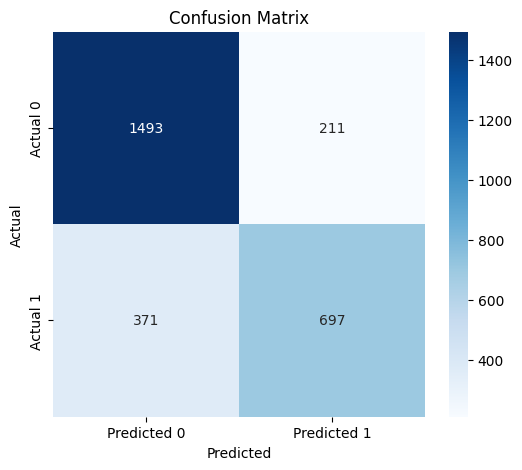

,Metric,Value
0,Accuracy,0.790043
1,Precision (Class 1),0.767621
2,Recall (Class 1),0.652622
3,F1 Score (Class 1),0.705466
4,ROC-AUC,0.864306


In [65]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score, precision_score, recall_score, f1_score



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1 Score (Class 1)', 'ROC-AUC'],
    'Value': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

metrics_table


The baseline Logistic Regression model achieved a strong ROC-AUC of 0.86, indicating excellent ability to distinguish between converting and non-converting leads. With 77% precision and 65% recall for converted leads, the model effectively prioritizes high-quality leads while maintaining reasonable coverage of actual converters. Overall accuracy of 79% suggests solid baseline performance, with potential for improvement through threshold tuning.

Random forest

In [66]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators= 200, random_state=42, max_depth=None)
rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)
y_prob_rf = rf_model.predict_proba(x_test)[:,1]


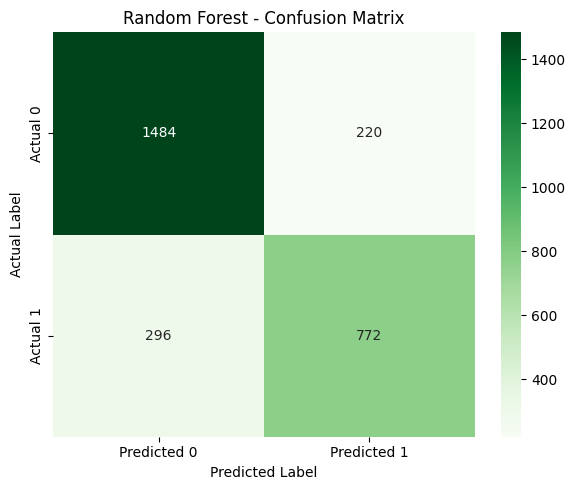

,Metric,Value
0,Accuracy,0.814
1,Precision (Class 1),0.778
2,Recall (Class 1),0.723
3,F1 Score (Class 1),0.750
4,ROC-AUC,0.881


In [67]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()


metrics_rf = pd.DataFrame({
    'Metric': ['Accuracy',
               'Precision (Class 1)',
               'Recall (Class 1)',
               'F1 Score (Class 1)',
               'ROC-AUC'],
    'Value': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

metrics_rf['Value'] = metrics_rf['Value'].round(3)

metrics_rf

XG Boost

In [68]:
from xgboost import XGBClassifier

!pip install xgboost

In [69]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(x_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:30:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [70]:
y_pred_xgb = xgb_model.predict(x_test)
y_prob_xgb = xgb_model.predict_proba(x_test)[:,1]

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd

metrics_xgb = pd.DataFrame({
    'Metric': ['Accuracy',
               'Precision (Class 1)',
               'Recall (Class 1)',
               'F1 Score (Class 1)',
               'ROC-AUC'],
    'Value': [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

metrics_xgb['Value'] = metrics_xgb['Value'].round(3)

metrics_xgb


,Metric,Value
0,Accuracy,0.823
1,Precision (Class 1),0.783
2,Recall (Class 1),0.748
3,F1 Score (Class 1),0.765
4,ROC-AUC,0.898


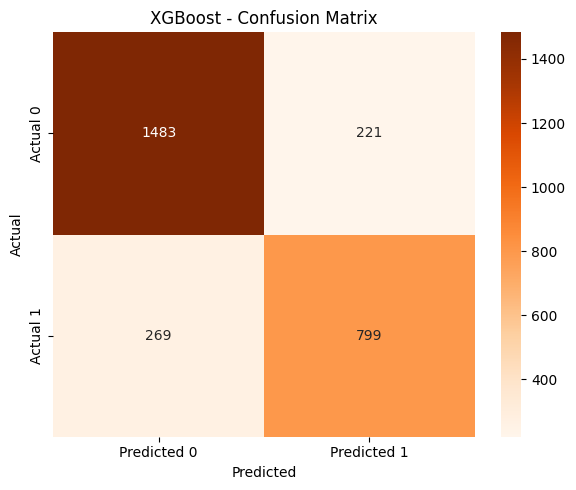

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb,
            annot=True,
            fmt='d',
            cmap='Oranges',
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost - Confusion Matrix')
plt.tight_layout()
plt.show()


Hyperparameter tunning- Grid search cv for xgboost

In [73]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'min_child_weight': [1, 3]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='precision',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Precision (CV):", grid_search.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:53:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300}
Best Precision (CV): 0.8054054458035115


In [76]:
best_xgb = grid_search.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(x_test)
y_prob_xgb_tuned = best_xgb.predict_proba(x_test)[:,1]


In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

metrics_xgb_tuned = pd.DataFrame({
    'Metric': ['Accuracy',
               'Precision (Class 1)',
               'Recall (Class 1)',
               'F1 Score (Class 1)',
               'ROC-AUC'],
    'Value': [
        accuracy_score(y_test, y_pred_xgb_tuned),
        precision_score(y_test, y_pred_xgb_tuned),
        recall_score(y_test, y_pred_xgb_tuned),
        f1_score(y_test, y_pred_xgb_tuned),
        roc_auc_score(y_test, y_prob_xgb_tuned)
    ]
})

metrics_xgb_tuned['Value'] = metrics_xgb_tuned['Value'].round(3)
metrics_xgb_tuned


,Metric,Value
0,Accuracy,0.829
1,Precision (Class 1),0.789
2,Recall (Class 1),0.757
3,F1 Score (Class 1),0.773
4,ROC-AUC,0.899


In [78]:
thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75]

results = []

for t in thresholds:
    y_pred_new = (y_prob_xgb_tuned > t).astype(int)

    results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_new),
        'Recall': recall_score(y_test, y_pred_new),
        'F1': f1_score(y_test, y_pred_new)
    })

pd.DataFrame(results)


,Threshold,Precision,Recall,F1
0,0.50,0.789268,0.757491,0.773053
1,0.55,0.804061,0.741573,0.771554
2,0.60,0.819869,0.703184,0.757056
3,0.65,0.832000,0.681648,0.749357
4,0.70,0.850708,0.618914,0.716531
5,0.75,0.884615,0.516854,0.652482


In [79]:
final_threshold = 0.65
y_pred_xgb_final = (y_prob_xgb_tuned > final_threshold).astype(int)


In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Random Forest',
              'XGBoost (Tuned)'],

    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb_final)
    ],

    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb_final)
    ],

    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb_final)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb_final)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb_tuned)
    ]
})

# Round values for clean presentation
comparison_table = comparison_table.round(3)

comparison_table


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.790,0.768,0.653,0.705,0.864
1,Random Forest,0.814,0.778,0.723,0.750,0.881
2,XGBoost (Tuned),0.824,0.832,0.682,0.749,0.899


In [81]:
comparison_table.style.highlight_max(color='lightgreen')


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.790000,0.768000,0.653000,0.705000,0.864000
1,Random Forest,0.814000,0.778000,0.723000,0.750000,0.881000
2,XGBoost (Tuned),0.824000,0.832000,0.682000,0.749000,0.899000


In [83]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Show top 10
feature_importance.head(10)


,Feature,Importance
5,Lead_Origin_Lead Add Form,0.255642
93,What_matters_most_to_you_in_choosing_a_course_...,0.129902
107,Last_Notable_Activity_SMS Sent,0.129126
91,What_is_your_current_occupation_Working Profes...,0.065812
2,Total_Time_Log,0.065451
23,Last_Activity_Olark Chat Conversation,0.034085
112,Funnel_Stage_Other,0.025783
19,Last_Activity_Email Opened,0.022184
66,Country_Unknown,0.019923
26,Last_Activity_SMS Sent,0.017438


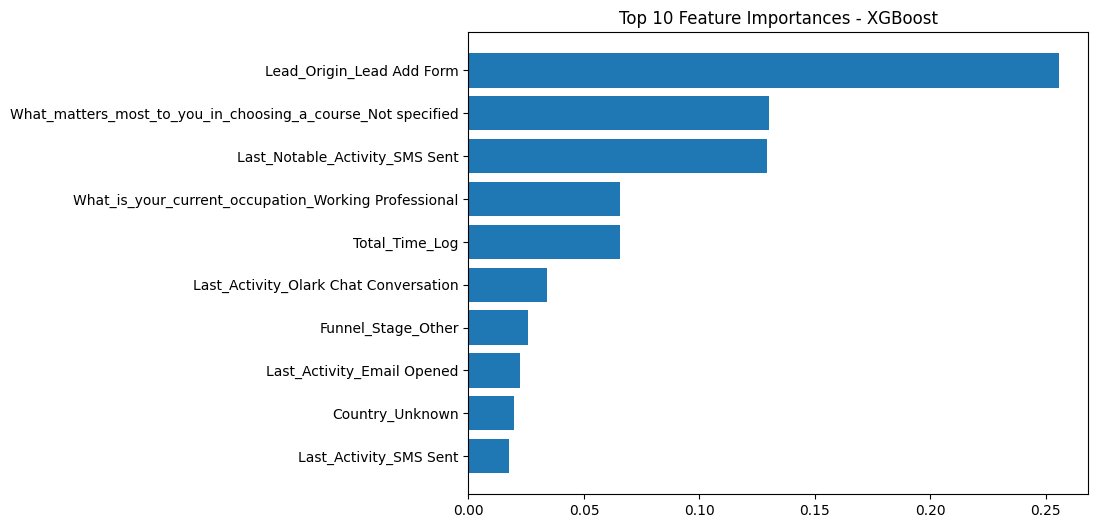

In [84]:
plt.figure(figsize=(8,6))
plt.barh(feature_importance['Feature'][:10],
         feature_importance['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - XGBoost")
plt.show()


**Overall Insights**

- Leads with higher engagement (more time spent on website and meaningful last activities like SMS Sent or Phone Conversations) showed significantly higher conversion rates, indicating that interaction depth strongly influences purchase intent.
- Certain lead sources such as reference-based leads and working professionals demonstrated much higher conversion likelihood compared to generic sources like organic search or direct traffic.
- Occupation played an important role, with working professionals converting at a much higher rate than students or unemployed leads.
- Engagement quality mattered more than visit frequency, suggesting that behavioral signals are more predictive than mere website traffic volume.




Business Recommendations (Based on EDA Findings)

- Prioritize high-engagement leads by setting automated alerts when users spend significant time on the website or actively respond to communication.

- Allocate more marketing budget toward high-performing lead sources (e.g., referrals and quality acquisition channels) while optimizing or reducing spend on low-converting channels.

- Tailor messaging specifically for high-converting segments like working professionals, while designing nurturing campaigns for lower-converting groups such as students.

- Strengthen follow-up strategies for leads showing strong behavioral intent signals (e.g., SMS interaction, phone conversations), as these are strong indicators of conversion readiness.